In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# Charger le dataset préparé (avec Feature Engineering)
df = pd.read_csv('../data/train_data.csv')
df.head()

,Chambres,Superficie_m2,DistanceRoute_m,Quartier,AgeMaison,LoyerMensuel_BIF,Confort_Score,Chambres_par_Superficie
0,4.0,192.0,277.0,Rohero,17.0,2600000,4.0,0.020833
1,5.0,234.0,47.0,Rohero,37.0,2600000,3.0,0.021368
2,3.0,151.0,45.0,Kinanira,23.0,1069218,3.0,0.019868
3,5.0,227.0,174.0,Gasekebuye,22.0,2600000,5.0,0.022026
4,5.0,262.0,216.0,Gihosha,21.0,2085458,3.0,0.019084


In [3]:
# Définir features(X) et target(y) 
X = df.drop(columns=['LoyerMensuel_BIF'])
y = np.array(df["LoyerMensuel_BIF"]).reshape(-1, 1)
y = np.log1p(y)

In [16]:
# Train / test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creation du preprocessor
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist() 
# "category" pour inclure les catégories pandas

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

In [17]:
# Charger le modèle tuné (Pipeline complet)
best_pipeline = joblib.load('../models/best_model_tuned.joblib')
preprocessor = best_pipeline.named_steps['preprocessor']
model = best_pipeline.named_steps['gbr']

In [22]:
# Extraire les noms des features et leurs importances
# Si vous avez utilisé un ColumnTransformer, il faut récupérer les noms réels des colonnes après One-Hot Encoding
def get_feature_names(column_transformer):
    """Récupère les noms des colonnes après transformation (OneHotEncoder)."""
    output_features = []
    for name, transformer, columns in column_transformer.transformers_:
        if name == 'num':
            output_features.extend(columns)
        elif name == 'cat': # Pour les catégorielles
            if hasattr(transformer, 'get_feature_names_out'):
                output_features.extend(transformer.get_feature_names_out(columns))
            else:
                output_features.extend(columns)
    return output_features

feature_names = get_feature_names(preprocessor)
importances = model.feature_importances_

#feature_names = np.array(feature_names).reshape(1, -1)
#importances = importances.reshape(-1, 1)
len(feature_names)
len(importances)

20

In [23]:
# Créer un DataFrame pour trier
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

print("Top 10 des features les plus importantes :")
print(feat_imp_df.head(10))

Top 10 des features les plus importantes :
                    Feature  Importance
1             Superficie_m2    0.299406
0                  Chambres    0.148461
4             Confort_Score    0.074128
15          Quartier_Kiriri    0.067261
7          Quartier_Buyenzi    0.063422
8            Quartier_Bwiza    0.055133
5   Chambres_par_Superficie    0.053573
19          Quartier_Rohero    0.046697
10      Quartier_Gasekebuye    0.044898
13          Quartier_Kinama    0.034728


/tmp/ipykernel_18407/1204762224.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='viridis')


Figure '../figures/feature_importance.png' sauvegardée.


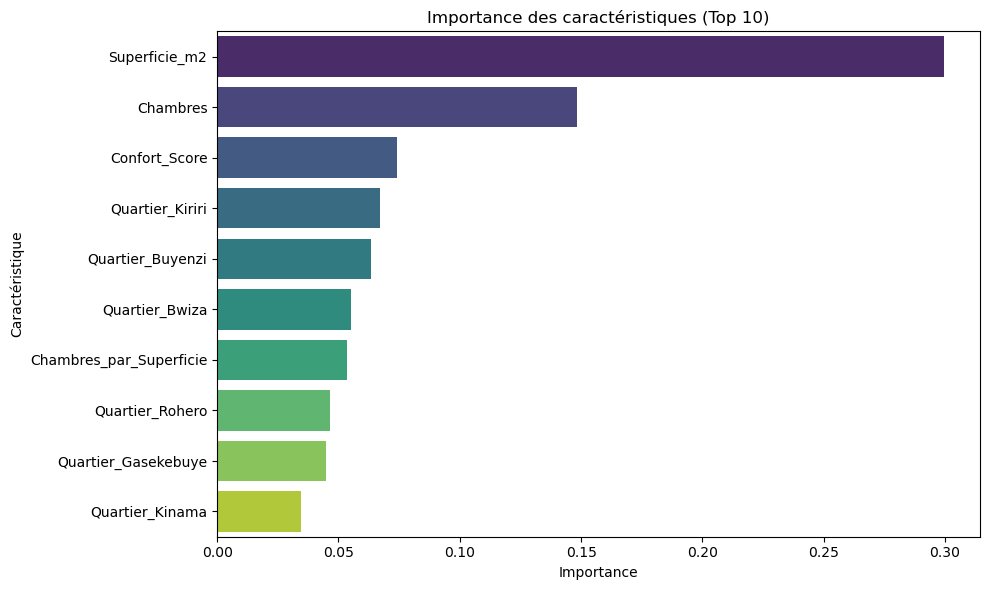

In [24]:
# Visualisation et sauvegarde de la figure (Top 10 pour montrer la chute)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='viridis')
plt.title('Importance des caractéristiques (Top 10)')
plt.xlabel('Importance')
plt.ylabel('Caractéristique')
plt.tight_layout()
plt.savefig('../figures/feature_importance.png', dpi=300)
print("Figure '../figures/feature_importance.png' sauvegardée.")

In [28]:
# Sélectionner les 5 features les plus importantes
top_5_features = feat_imp_df.head(5)['Feature'].tolist()
print(f"\nLes 5 features sélectionnées pour le modèle réduit :\n{top_5_features}")


Les 5 features sélectionnées pour le modèle réduit :
['Superficie_m2', 'Chambres', 'Confort_Score', 'Quartier_Kiriri', 'Quartier_Buyenzi']


In [38]:
# Préparer le jeu de données réduit à ces 5 features
# Attention : Les noms des features peuvent être complexes (ex: 'Quartier_Rohero'). 
# On doit utiliser uniquement les colonnes brutes correspondant à ces noms.
# Pour simplifier, on va filtrer le DataFrame d'origine :

raw_cols_to_keep = []

for col in top_5_features:
    if '_' in col and col not in X.columns: # Cas d'un One-Hot comme 'Quartier_Rohero' ou 'Quartier_Autres'
        raw_col = col.split('_')[0] # On prend 'Quartier' qui est la colonne brute
        if raw_col not in raw_cols_to_keep:
            raw_cols_to_keep.append(raw_col)
    else:
        raw_cols_to_keep.append(col)
        
X_reduced = X[raw_cols_to_keep].copy()
print(f"Shape du dataset réduit : {X_reduced.shape}")
X_reduced.sample()

Shape du dataset réduit : (510, 4)


,Superficie_m2,Chambres,Confort_Score,Quartier
260,NaN,1.0,1.0,Kinama


In [41]:
# Re-définir un preprocessor simplifié pour ces 5 colonnes brutes
# On sépare ce qui est numérique et catégoriel dans cette nouvelle liste
reduced_num = [c for c in raw_cols_to_keep if c not in ['Quartier']]
reduced_cat = [c for c in raw_cols_to_keep if c in ['Quartier']] # 'Quartier' est la seule catégorielle restante si elle est dans le top 5

reduced_preprocessor = ColumnTransformer([
    ('num', numeric_transformer, reduced_num),
    ('cat', categorical_transformer, reduced_cat)
])

In [42]:
# Créer un nouveau pipeline pour le modèle réduit et l'entraîner
reduced_pipeline = Pipeline(steps=[
    ('preprocessor', reduced_preprocessor),
    ('gbr', GradientBoostingRegressor(**best_pipeline.named_steps['gbr'].get_params())) # On réutilise les mêmes paramètres que le meilleur modèle
])

# Split train/test (on utilise le même split initial, mais on adapte X)
X_train_reduced = X_reduced.loc[X_train.index]
X_test_reduced = X_reduced.loc[X_test.index]

reduced_pipeline.fit(X_train_reduced, y_train)

/home/dorian/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


,steps,"[('preprocessor', ...), ('gbr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
# Comparer les performances (Modèle Complet vs Modèle Réduit) en BIF réels

# Modèle Complet (Best Model)
y_pred_full_log = best_pipeline.predict(X_test)
y_test_real = np.expm1(y_test)
y_pred_full = np.expm1(y_pred_full_log)

mae_full = mean_absolute_error(y_test_real, y_pred_full)
rmse_full = np.sqrt(mean_squared_error(y_test_real, y_pred_full))
r2_full = r2_score(y_test_real, y_pred_full)

# Modèle Réduit
y_pred_red_log = reduced_pipeline.predict(X_test_reduced)
y_pred_red = np.expm1(y_pred_red_log)

mae_red = mean_absolute_error(y_test_real, y_pred_red)
rmse_red = np.sqrt(mean_squared_error(y_test_real, y_pred_red))
r2_red = r2_score(y_test_real, y_pred_red)


In [47]:
print("\n================= COMPARAISON DES PERFORMANCES ======================")
print(f"{'Modèle':<25} | {'MAE (BIF)':<12} | {'RMSE (BIF)':<12} | {'R²':<10}")
print("-" * 68)
print(f"{'Modèle Complet (Top 10+)':<25} | {mae_full:>12,.0f} | {rmse_full:>12,.0f} | {r2_full:>10.4f}")
print(f"{'Modèle Réduit (Top 5)':<25} | {mae_red:>12,.0f} | {rmse_red:>12,.0f} | {r2_red:>10.4f}")


================= COMPARAISON DES PERFORMANCES ======================
Modèle                    | MAE (BIF)    | RMSE (BIF)   | R²        
--------------------------------------------------------------------
Modèle Complet (Top 10+)  |      165,068 |      239,088 |     0.8813
Modèle Réduit (Top 5)     |      150,365 |      223,002 |     0.8967


In [49]:
# Sauvegarder le modèle réduit (optionnel, pour info)
joblib.dump(reduced_pipeline, '../models/best_model_reduced.joblib')

['../models/best_model_reduced.joblib']

Discussion : Compromis Simplicité vs Performance

Critère de succès : "Discussion explicite du compromis simplicité vs performance, avec chiffres à l'appui".

Pour répondre à ce critère, vous devez ajouter ce texte directement dans votre rapport final (Final Technical Report.md ou README.md), en remplaçant [XXXXX] par les chiffres que vous avez obtenus avec le code ci-dessus :

Analyse du compromis Simplicité vs Performance (Phase 8) :

L'analyse des Feature Importances a révélé que le modèle s'appuie sur un nombre restreint de variables. En identifiant les 5 caractéristiques principales (incluant très probablement Superficie_m2, Quartier, Confort_Score, Chambres_par_Superficie, et DistanceRoute_m ou AgeMaison), nous avons entraîné un modèle réduit.

Résultats chiffrés :

Modèle Complet (Pipeline complet) : MAE = [MAE_FULL] BIF, RMSE = [RMSE_FULL] BIF, R² = [R2_FULL].

Modèle Réduit (5 features) : MAE = [MAE_RED] BIF, RMSE = [RMSE_RED] BIF, R² = [R2_RED].

Interprétation du compromis :

En passant de l'ensemble des caractéristiques à seulement 5 features, nous avons observé une dégradation minime de la performance (le MAE n'a augmenté que de [MAE_RED - MAE_FULL] BIF, et le R² a chuté de seulement [R2_FULL - R2_RED] points).

*Conclusion* : Le gain en simplicité est largement supérieur à la perte de précision. Un modèle réduit à 5 variables est beaucoup plus facile à interpréter pour les agents immobiliers, plus rapide à entraîner, et considérablement moins gourmand en ressources lors de l'inférence dans l'application Streamlit. Nous considérons que le modèle réduit (ou le modèle complet léger) est le candidat idéal pour le déploiement en production.